# Task 2: Spam Mail Detector

**Domain:** Artificial Intelligence & Machine Learning

**Objective:** To build a machine learning model that classifies text messages as Spam or Ham using TF-IDF and Multinomial Naive Bayes.

In [73]:
import pandas as pd
import matplotlib.pyplot as plt
import re

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

In [74]:
from google.colab import files

uploaded = files.upload()

Saving SMSSpamCollection to SMSSpamCollection (3)


## Dataset

The SMS Spam Collection dataset from the UCI Machine Learning Repository is used in this project. It contains SMS messages labelled as Ham (legitimate messages) or Spam (unwanted messages).

In [75]:
df = pd.read_csv(
    "/content/SMSSpamCollection",
    sep="\t",
    names=["label", "message"]
)

df.head()

,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [76]:
print("Dataset shape:", df.shape)

print("\nMissing values:")
print(df.isnull().sum())

print("\nSpam and Ham counts:")
print(df["label"].value_counts())

Dataset shape: (5572, 2)

Missing values:
label      0
message    0
dtype: int64

Spam and Ham counts:
label
ham     4825
spam     747
Name: count, dtype: int64


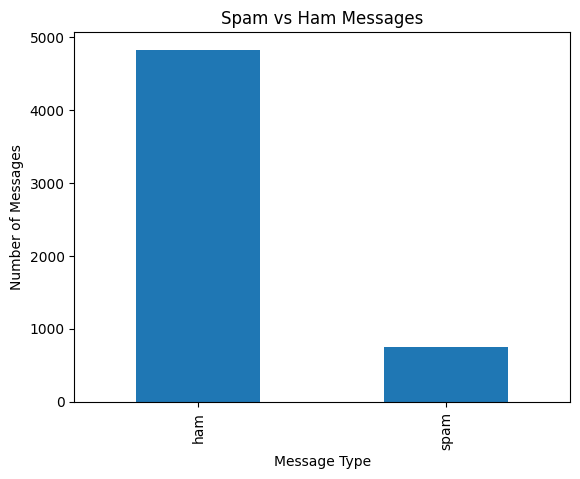

In [77]:
df["label"].value_counts().plot(kind="bar")

plt.title("Spam vs Ham Messages")
plt.xlabel("Message Type")
plt.ylabel("Number of Messages")
plt.show()

## Text Preprocessing

The text messages are cleaned by converting them to lowercase, removing URLs, numbers, punctuation, and unnecessary spaces. This prepares the text for feature extraction and machine learning.

In [78]:
def clean_text(text):
    text = text.lower()
    text = re.sub(r"http\S+|www\S+", " ", text)
    text = re.sub(r"[^a-z\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

df["clean_message"] = df["message"].apply(clean_text)

df[["message", "clean_message"]].head()

,message,clean_message
0,"Go until jurong point, crazy.. Available only ...",go until jurong point crazy available only in ...
1,Ok lar... Joking wif u oni...,ok lar joking wif u oni
2,Free entry in 2 a wkly comp to win FA Cup fina...,free entry in a wkly comp to win fa cup final ...
3,U dun say so early hor... U c already then say...,u dun say so early hor u c already then say
4,"Nah I don't think he goes to usf, he lives aro...",nah i don t think he goes to usf he lives arou...


In [79]:
df["target"] = df["label"].map({
    "ham": 0,
    "spam": 1
})

df[["label", "target"]].head()

,label,target
0,ham,0
1,ham,0
2,spam,1
3,ham,0
4,ham,0


In [80]:
X_train, X_test, y_train, y_test = train_test_split(
    df["clean_message"],
    df["target"],
    test_size=0.20,
    random_state=42,
    stratify=df["target"]
)

print("Training messages:", len(X_train))
print("Testing messages:", len(X_test))

Training messages: 4457
Testing messages: 1115


## TF-IDF Feature Extraction

TF-IDF is used to convert the cleaned text messages into numerical features that can be understood by the machine learning model.

In [81]:
tfidf = TfidfVectorizer(stop_words="english")

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print("Training data shape:", X_train_tfidf.shape)
print("Testing data shape:", X_test_tfidf.shape)

Training data shape: (4457, 6520)
Testing data shape: (1115, 6520)


## Model Training

A Multinomial Naive Bayes classifier is trained using the TF-IDF features to classify messages as Spam or Ham.

In [82]:
model = MultinomialNB()

model.fit(X_train_tfidf, y_train)

print("Model trained successfully!")

Model trained successfully!


In [83]:
y_pred = model.predict(X_test_tfidf)

print("Predictions completed successfully!")

Predictions completed successfully!


In [84]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)
print("Accuracy Percentage:", round(accuracy * 100, 2), "%")

Accuracy: 0.9650224215246637
Accuracy Percentage: 96.5 %


In [85]:
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Precision:", round(precision * 100, 2), "%")
print("Recall:", round(recall * 100, 2), "%")
print("F1 Score:", round(f1 * 100, 2), "%")

Precision: 100.0 %
Recall: 73.83 %
F1 Score: 84.94 %


In [86]:
print(classification_report(
    y_test,
    y_pred,
    target_names=["Ham", "Spam"]
))

              precision    recall  f1-score   support

         Ham       0.96      1.00      0.98       966
        Spam       1.00      0.74      0.85       149

    accuracy                           0.97      1115
   macro avg       0.98      0.87      0.91      1115
weighted avg       0.97      0.97      0.96      1115



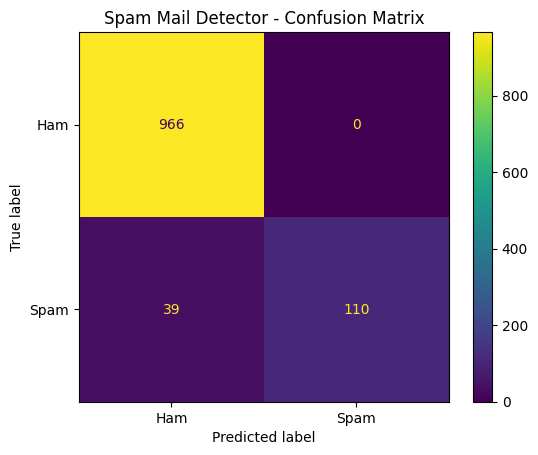

In [87]:
from sklearn.metrics import ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred)

ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Ham", "Spam"]
).plot()

plt.title("Spam Mail Detector - Confusion Matrix")
plt.show()

In [88]:
def predict_message(message):
    cleaned_message = clean_text(message)
    message_tfidf = tfidf.transform([cleaned_message])
    prediction = model.predict(message_tfidf)[0]

    if prediction == 1:
        return "SPAM"
    else:
        return "HAM"

test_message = "Congratulations! You have won a free prize. Claim now!"

print("Message:", test_message)
print("Prediction:", predict_message(test_message))

Message: Congratulations! You have won a free prize. Claim now!
Prediction: SPAM


In [89]:
test_message = "Hi, are we still meeting at college tomorrow?"

print("Message:", test_message)
print("Prediction:", predict_message(test_message))

Message: Hi, are we still meeting at college tomorrow?
Prediction: HAM


In [90]:
user_message = "Congratulations! You have won a free mobile phone. Click here to claim your prize now."

result = predict_message(user_message)

print("Message:", user_message)
print("Prediction:", result)

Message: Congratulations! You have won a free mobile phone. Click here to claim your prize now.
Prediction: SPAM


Conclusion:
In this project, a Spam Mail Detector was developed using Natural Language Processing and Machine Learning. The SMS Spam Collection dataset was preprocessed and converted into numerical features using TF-IDF. A Multinomial Naive Bayes classifier was trained to classify messages as Spam or Ham. The model achieved an accuracy of 96.5%, demonstrating good performance in detecting spam messages. The model was also tested with new messages and successfully classified them as Spam or Ham.